In [1]:
pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [43]:
token = "hf_REDACTED"
from huggingface_hub import login
login(token)

In [44]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "meta-llama/Llama-3.2-1B"
tokenizer = AutoTokenizer.from_pretrained(model_id, token=token)
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", torch_dtype=torch.float16)


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]



```
# This is formatted as code
```

<h1><b>Sentiment Analysis</b></h1>

---
Dataset : IMDB ,
Totall Samples : 1000

In [85]:
def batch_zero_shot_prompt(review):
    return f"""You are a sentiment analysis expert.

Review: "{review[0]}"

What is the sentiment of movie review above.Choose only one of the following:
- Positive
- Negative

Respond with one word only:

Answer:"""

In [86]:
import re
def extract_sentiment(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(Positive|Negative)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [87]:
from datasets import load_dataset

# Load the IMDb test subset
dataset = load_dataset("imdb", split="test")
shuffled_dataset = dataset.shuffle(seed=42)

Samples = shuffled_dataset.select(range(1000))

# IMDb labels: 0 = negative, 1 = positive
label_counts = {"positive": 0, "negative": 0}

# Count positive and negative labels
for example in Samples:
    label = example["label"]
    if label == 1:
        label_counts["positive"] += 1
    else:
        label_counts["negative"] += 1

print("Total reviews:", len(dataset))
print("Positive reviews:", label_counts["positive"])
print("Negative reviews:", label_counts["negative"])


Total reviews: 25000
Positive reviews: 488
Negative reviews: 512


In [88]:
texts = []
true_labels = []
for i in range (0,len(Samples['text'])):
    texts.append(Samples['text'][i])
for i in range (0,len(Samples['text'])):
    true_labels.append(Samples['label'][i])
print(Samples)
print(len(texts))
print(len(true_labels))

Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
1000
1000


In [89]:
pip install codecarbon

In [90]:
from codecarbon import EmissionsTracker

tracker = EmissionsTracker(
    project_name="phi4-imdb-inference",
    output_dir=".",          # where the CSV will be saved
    tracking_mode="process", # tracks CPU/GPU for this process only
    measure_power_secs=5,
    log_level="error"
)


In [51]:
batch_size = 1
predicted_labels = []

tracker.start()

for i in range(0, len(Samples), batch_size):
    batch = Samples[i:i+batch_size]["text"]
    # print(f"=== Batch {i//batch_size + 1} ===")
    prompt = batch_zero_shot_prompt(batch)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    output = model.generate(**inputs, max_new_tokens=5)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    # print(decoded)
    prediction = extract_sentiment(decoded)
    predicted_labels.append(prediction)

emissions = tracker.stop()


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

In [52]:
inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
output = model.generate(**inputs, max_new_tokens=10)
decoded = tokenizer.decode(output[0], skip_special_tokens=True)
print(decoded)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


You are a sentiment analysis expert.

Review: "This is the best version of Gypsy that has been filmed.Bette Midler is simply superb as Mama Rose.She has the voice,the gestures,the look,and most of all,a supreme acting ability to carry the role off and to make her character come alive.Her singing is,simply put:MAGNIFICENT! She especially shines in two numbers-"Everything's Coming Up Roses" and "Rose's Turn". The other actors are also fine,particularly Christine Ebersoll as Tessie.Also good is Peter Riegert;his portrayal of Herbie is acted with great style and believability.The direction of this movie is very,very good.There isn't a false note or gaffe in the entire production.This film is a vast improvement over the Roz Russell version filmed in 1962.Since viewing it again,I can state that the three greatest Mama Roses are:Ethel Merman,Bette Midler,and Angela Lansbury. See this movie.You'll be glad that you did."

What is the sentiment of movie review above.Choose only one of the follow

In [53]:
# Map predictions to 0/1
predictions = [1 if s == "Positive" else 0 for s in predicted_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)



Accuracy: 0.58
F1 Score: 0.587426326129666
Recall: 0.6127049180327869
Precision: 0.5641509433962264


In [54]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 50
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : phi4-imdb-inference
Duration (s)           : 132.12

--- Energy ---
Total energy (kWh)     : 0.004323
Energy per sample (J)  : 311.25
Energy per 1k samples (kJ): 0.31

--- Carbon ---
CO₂ emissions (kg)     : 0.000017
CO₂ per sample (g)     : 0.0003

--- Time ---
Avg time per sample (s): 2.642

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.00GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : Canada
Cloud provider         : nan
Tracking mode          : process




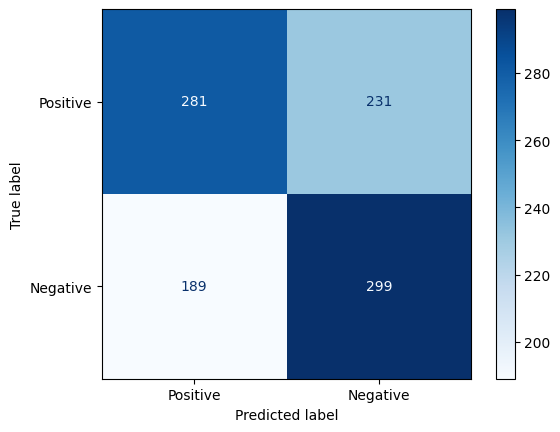

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positive", "Negative"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

<h1><b>Hate Speech Detection</b></h1>

---
Dataset : OLID ,
Totall Samples : 400



In [56]:
from datasets import load_dataset

dataset = load_dataset("christophsonntag/OLID", split="test")
dataset[5]


{'id': 83681,
 'tweet': '. . . What the fuck did he do this time?',
 'cleaned_tweet': 'fuck time',
 'subtask_a': 'OFF',
 'subtask_b': 'TIN',
 'subtask_c': 'IND'}

In [57]:
dataset

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 860
})

In [58]:
shuffled_dataset = dataset.shuffle(seed=42).select(range(800))

shuffled_dataset

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 800
})

In [59]:
negatives = shuffled_dataset.filter(lambda x: x['subtask_a'] == 'OFF').select(range(200))
positives = shuffled_dataset.filter(lambda x: x['subtask_a'] == 'NOT').select(range(200))

# Combine both subsets
from datasets import concatenate_datasets
Samples = concatenate_datasets([negatives, positives])

In [60]:
Samples = Samples.shuffle()

In [61]:
label_counts = {"OFF": 0, "NOT": 0}

# Count positive and negative labels
for example in Samples:
    label = example["subtask_a"]
    if label == 'OFF':
        label_counts["OFF"] += 1
    else:
        label_counts["NOT"] += 1

print("Total tweets:", len(Samples))
print("Offensive tweets:", label_counts["OFF"])
print("Non-offensive tweets:", label_counts["NOT"])

Total tweets: 400
Offensive tweets: 200
Non-offensive tweets: 200


In [62]:
tweets = []
true_labels = []
for i in range (0,len(Samples['tweet'])):
    tweets.append(Samples['cleaned_tweet'][i])
for i in range (0,len(Samples['tweet'])):
    true_labels.append(Samples['subtask_a'][i])
print(Samples)
print(len(tweets))
print(len(true_labels))

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 400
})
400
400


In [63]:
tweets[0]

'6 got angry stating checked drawer see making argument could still fault particular instance ohreally'

In [64]:
def batch_zero_shot_prompt(review):
    return f"""Read this tweet below :

Tweet: "{review[0]}"

Now tell me if the tweet is :
- Offensive
- Non-offensive

Answer in one word only.

Answer:
"""


In [65]:
import re
def extract_detection(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(Offensive|Non-offensive)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [66]:
batch_size = 1
predicted_labels = []

for i in range(0, len(Samples['tweet']), batch_size):
    batch = Samples[i:i+batch_size]["tweet"]
    # print(f"=== Batch {i//batch_size + 1} ===")
    prompt = batch_zero_shot_prompt(batch)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,max_length=512).to(model.device)
    output = model.generate(**inputs, max_new_tokens=5,eos_token_id=tokenizer.eos_token_id,early_stopping=True)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    # print(decoded)
    prediction = extract_detection(decoded)
    predicted_labels.append(prediction)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

In [67]:
# Map predictions to 0/1
predictions = [1 if s == "Offensive" else 0 for s in predicted_labels]
actual = [1 if s == 'OFF' else 0 for s in true_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(actual, predictions)
f1 = f1_score(actual, predictions)
recall = recall_score(actual, predictions)
precision = precision_score(actual, predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)


Accuracy: 0.515
F1 Score: 0.5975103734439834
Recall: 0.72
Precision: 0.5106382978723404


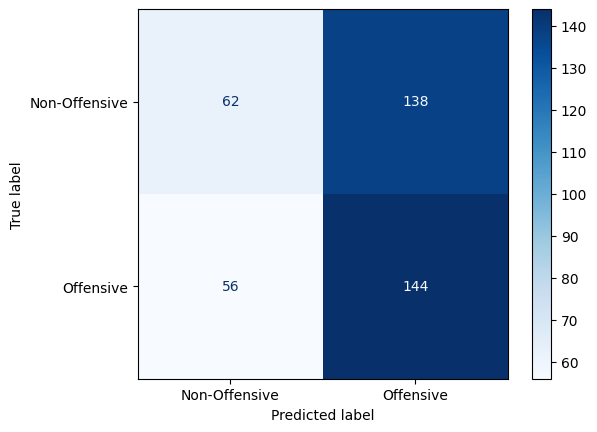

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(actual, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Offensive", "Offensive"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [69]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 50
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : phi4-imdb-inference
Duration (s)           : 132.12

--- Energy ---
Total energy (kWh)     : 0.004323
Energy per sample (J)  : 311.25
Energy per 1k samples (kJ): 0.31

--- Carbon ---
CO₂ emissions (kg)     : 0.000017
CO₂ per sample (g)     : 0.0003

--- Time ---
Avg time per sample (s): 2.642

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.00GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : Canada
Cloud provider         : nan
Tracking mode          : process




<h1><b>News Classification</b></h1>

---



In [70]:
from datasets import load_dataset
print("=== AG News ===")
ag_news = load_dataset("ag_news", split="test")
ag_news

=== AG News ===


Dataset({
    features: ['text', 'label'],
    num_rows: 7600
})

In [71]:
ag_news.features['label']

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])

In [72]:
ag_news[4]

{'text': "Calif. Aims to Limit Farm-Related Smog (AP) AP - Southern California's smog-fighting agency went after emissions of the bovine variety Friday, adopting the nation's first rules to reduce air pollution from dairy cow manure.",
 'label': 3}

In [73]:
World = ag_news.filter(lambda x: x['label'] == 0).select(range(150))
Sports = ag_news.filter(lambda x: x['label'] == 1).select(range(150))
Business = ag_news.filter(lambda x: x['label'] == 2).select(range(150))
SciTech = ag_news.filter(lambda x: x['label'] == 3).select(range(150))

from datasets import concatenate_datasets
Samples = concatenate_datasets([World, Sports,Business,  SciTech])

In [74]:
Samples[42]

{'text': 'Israelis OK new homes in West Bank A leaked Israeli plan to build 1,000 new Jewish settler homes in the West Bank yesterday sent Bush administration officials scrambling for a response in the sensitive period before November #39;s presidential election. ',
 'label': 0}

In [75]:
Samples = Samples.shuffle()

In [76]:
label_counts = {"World":0, "Sports": 0, "Business" :0, "Sci/Tech": 0}

# Count labels
for example in Samples:
    label = example["label"]
    if label == 0:
        label_counts["World"] += 1
    elif label == 1:
        label_counts["Sports"] += 1
    elif label == 2:
        label_counts["Business"] += 1
    else:
        label_counts["Sci/Tech"] += 1

print("Total :", len(Samples))
print("World:", label_counts["World"])
print("Sports:", label_counts["Sports"])
print("Business:", label_counts["Business"])
print("Sci/Tech", label_counts["Sci/Tech"])

Total : 600
World: 150
Sports: 150
Business: 150
Sci/Tech 150


In [77]:
news = []
true_labels = []
for example in Samples:
    emotion = example["text"]
    label = example["label"]
    news.append(emotion)
    true_labels.append(label)

print(Samples)
print(len(news))
print(len(true_labels))

Dataset({
    features: ['text', 'label'],
    num_rows: 600
})
600
600


In [78]:
print(Samples[300])
print(news[300])
print(true_labels[300])

{'text': 'FOAFKey: FOAF, PGP, Key Distribution, and Bloom Filters \\\\FOAF/LOAF  and bloom filters have a lot of interesting properties for social\\network and whitelist distribution.\\\\I think we can go one level higher though and include GPG/OpenPGP key\\fingerpring distribution in the FOAF file for simple web-of-trust based key\\distribution.\\\\What if we used FOAF and included the PGP key fingerprint(s) for identities?\\This could mean a lot.  You include the PGP key fingerprints within the FOAF\\file of your direct friends and then include a bloom filter of the PGP key\\fingerprints of your entire whitelist (the source FOAF file would of course need\\to be encrypted ).\\\\Your whitelist would be populated from the social network as your client\\discovered new identit ...\\\\', 'label': 3}
FOAFKey: FOAF, PGP, Key Distribution, and Bloom Filters \\FOAF/LOAF  and bloom filters have a lot of interesting properties for social\network and whitelist distribution.\\I think we can go one

In [79]:
def news_classification_prompt(article):
    return f"""You are an AI assistant trained to classify news articles based on their content.

Article: "{article[0]}"

Classify the article into one of the following categories:
- World
- Sports
- Business
- SciTech

Answer in one word only.

Answer:"""

In [80]:
import re
def extract_sentiment(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(World|Sports|Business|SciTech)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [81]:
batch_size = 1
predicted_labels = []

for i in range(0, len(Samples), batch_size):
    batch= Samples[i:i+batch_size]["text"]
    # print(f"=== Batch {i//batch_size + 1} ===")
    prompt = news_classification_prompt(batch)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    output = model.generate(**inputs, max_new_tokens=5,eos_token_id=tokenizer.eos_token_id,early_stopping=True)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    # print(decoded)
    prediction = extract_sentiment(decoded)
    predicted_labels.append(prediction)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

In [82]:
# Map predictions to 0/1
label_map = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Scitech": 3
}

predictions = [label_map[s] for s in predicted_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions, average='macro')
recall = recall_score(true_labels, predictions, average='macro')
precision = precision_score(true_labels, predictions, average='macro')

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)


Accuracy: 0.295
F1 Score: 0.25850325300380317
Recall: 0.29500000000000004
Precision: 0.33666195732221377


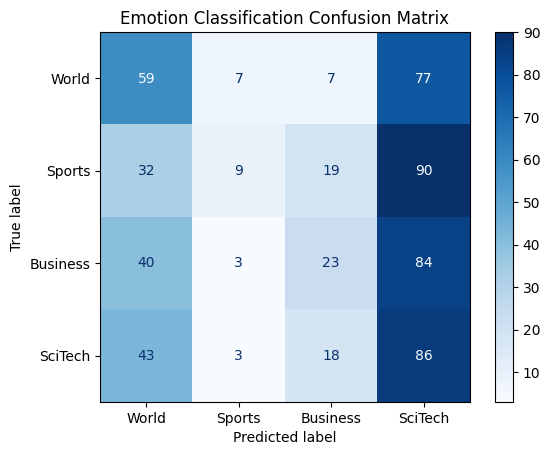

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["World","Sports", "Business","SciTech"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Emotion Classification Confusion Matrix")
plt.show()

In [84]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 50
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : phi4-imdb-inference
Duration (s)           : 132.12

--- Energy ---
Total energy (kWh)     : 0.004323
Energy per sample (J)  : 311.25
Energy per 1k samples (kJ): 0.31

--- Carbon ---
CO₂ emissions (kg)     : 0.000017
CO₂ per sample (g)     : 0.0003

--- Time ---
Avg time per sample (s): 2.642

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.00GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : Canada
Cloud provider         : nan
Tracking mode          : process


